In [1]:
import pandas as pd
import numpy as np
import sys
import os
from tqdm import tqdm
import sys

In [2]:
sys.path.append('../src/')

In [3]:
from visualization import *

# Data import

In [4]:
all_metrics = pd.read_csv('../data/all_metrics.csv')

# Compute Authorship Calibration

In [5]:
all_metrics['calibration'] = all_metrics['written_by_human_decla'].astype(int) - all_metrics['written_by_human'].astype(int)
all_metrics['calibration_score'] = all_metrics['calibration'] / 100

all_metrics['abs_calibration_score'] = all_metrics['calibration_score'].abs()

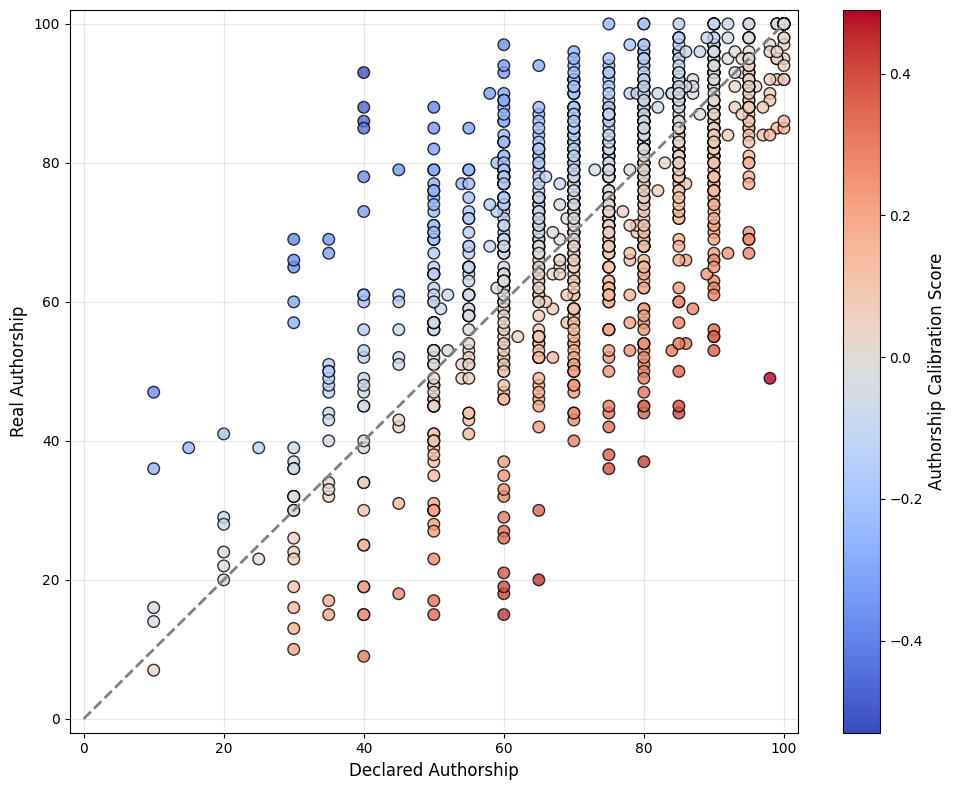

In [6]:
data_raw = all_metrics[['written_by_human_decla', 'written_by_human', 'calibration_score']]
plot_calibration_scores(data_raw, color_map='coolwarm', name_fig='raw', save_fig=True)

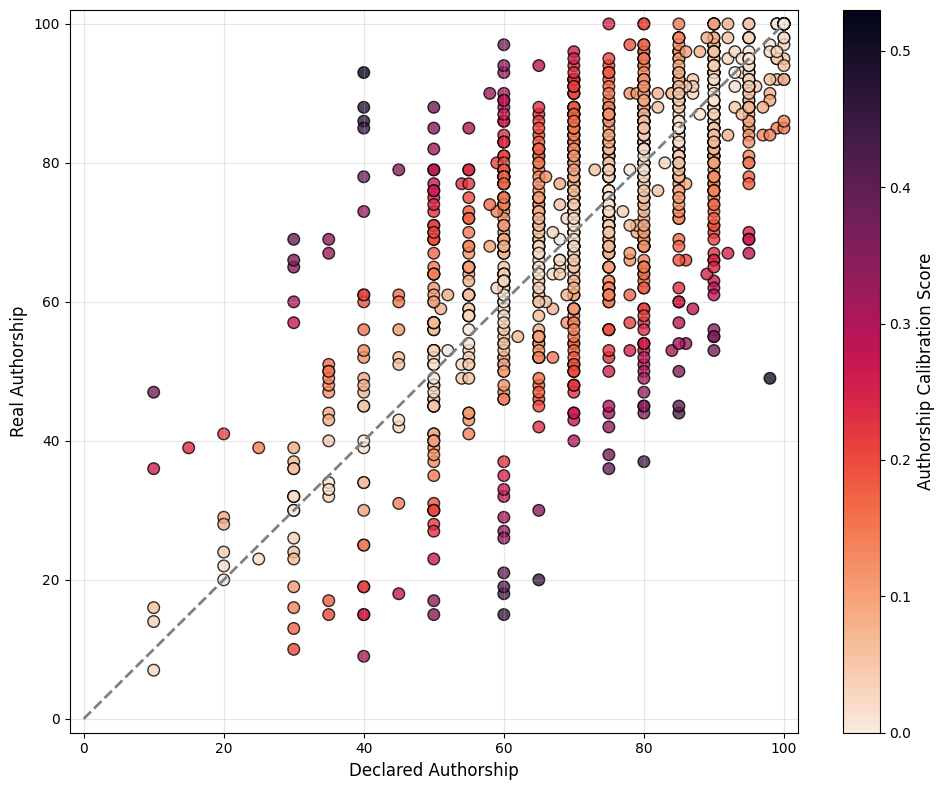

In [7]:
data_abs = all_metrics[['written_by_human_decla', 'written_by_human', 'abs_calibration_score']]
plot_calibration_scores(data_abs, color_map='rocket_r', name_fig='abs', save_fig=True)

# Explore variations across GenAI interaction dynamics

In [8]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from scipy.stats import normaltest
import scipy.stats as stats
from scipy.stats import mannwhitneyu, kstest
from scipy.stats import probplot
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Raw calibration scores

### LMM model

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: calibration_score
No. Observations: 1241    Method:             REML             
No. Groups:       60      Scale:              0.0119           
Min. group size:  1       Log-Likelihood:     913.2740         
Max. group size:  87      Converged:          Yes              
Mean group size:  20.7                                         
----------------------------------------------------------------
                 Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------
C(cluster)[0]     0.096     0.020   4.744  0.000   0.056   0.136
C(cluster)[1]    -0.011     0.015  -0.726  0.468  -0.040   0.018
C(cluster)[2]    -0.010     0.016  -0.656  0.512  -0.041   0.020
C(cluster)[3]     0.050     0.016   3.094  0.002   0.018   0.082
C(cluster)[4]    -0.038     0.013  -2.817  0.005  -0.064  -0.011
C(cluster)[5]     0.064     0.021   3.049  0.

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


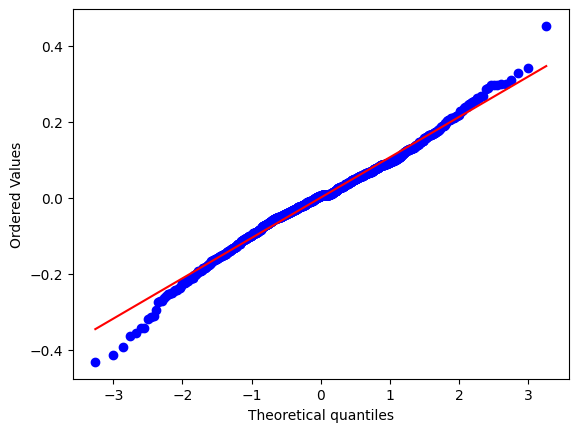

In [9]:
# Ensure cluster is treated as categorical (e.g., C(cluster_id))
all_metrics["cluster"] = all_metrics["cluster"].astype("category")

# 1. Fit the Linear Mixed Model
# 'abs_calibration_score ~ C(cluster_id)' automatically creates dummy variables
lmm_cluster_raw = smf.mixedlm(
    "calibration_score ~ C(cluster) - 1",
    data=all_metrics,
    groups=all_metrics["worker_id"],
)
lmm_cluster_raw_result = lmm_cluster_raw.fit()
print(lmm_cluster_raw_result.summary())

residuals = lmm_cluster_raw_result.resid
probplot(residuals, dist="norm", plot=plt)
plt.title("")
plt.show()

In [10]:
# Extract model-based means and 95% confidence intervals for each cluster
fixed_effects = lmm_cluster_raw_result.fe_params
cov_matrix = lmm_cluster_raw_result.cov_params().loc[fixed_effects.index, fixed_effects.index]

clusters = sorted(all_metrics["cluster"].unique())
means = []
ci_lower = []
ci_upper = []

for cluster in clusters:
    param_name = f"C(cluster)[{cluster}]"
    mean = float(fixed_effects[param_name])
    standard_error = float(np.sqrt(cov_matrix.loc[param_name, param_name]))
    means.append(mean)
    ci_lower.append(mean - 1.96 * standard_error)
    ci_upper.append(mean + 1.96 * standard_error)

df_emmeans = pd.DataFrame(
    {
        "cluster_id": clusters,
        "mean": means,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
    }
)

df_emmeans

,cluster_id,mean,ci_lower,ci_upper
0,0,0.095902,0.056282,0.135522
1,1,-0.010738,-0.039741,0.018265
2,2,-0.010199,-0.040669,0.020271
3,3,0.050406,0.018470,0.082342
4,4,-0.037735,-0.063985,-0.011484
5,5,0.064482,0.023037,0.105927


### Wald $\chi^2$ test

In [11]:
hypothesis = hypothesis = (
    "C(cluster)[0] = C(cluster)[1], "
    "C(cluster)[0] = C(cluster)[2], " 
    "C(cluster)[0] = C(cluster)[3], "
    "C(cluster)[0] = C(cluster)[4], "
    "C(cluster)[0] = C(cluster)[5]"
)


wald_test = lmm_cluster_raw_result.wald_test(hypothesis)
print(f"Chi2: {wald_test.statistic}")
print(f"p-value: {wald_test.pvalue}")

Chi2: [[85.10846298]]
p-value: 7.14375623659851e-17


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### T-test for pairwise comparison (with Bonferroni correction)

In [12]:
# 1. Get the fixed-effects parameter names
fe_params = list(lmm_cluster_raw_result.fe_params.index)
n_params = len(fe_params)

# 2. Iterate over all pairs of clusters
pairwise_results = []

for p1, p2 in combinations(fe_params, 2):
    r_matrix = np.zeros(n_params)
    r_matrix[fe_params.index(p1)] = 1
    r_matrix[fe_params.index(p2)] = -1
    r_matrix = r_matrix.reshape(1, -1)  # Reshape to 2D for the t_test function

    # Run the t-test with the NumPy matrix
    test = lmm_cluster_raw_result.t_test(r_matrix)

    # Safely extract the values
    diff = float(np.asarray(test.effect).squeeze())
    sd = float(np.asarray(test.sd).squeeze())
    z_stat = float(np.asarray(test.tvalue).squeeze())
    p_val = float(np.asarray(test.pvalue).squeeze())

    # Clean up names for readability in the table
    label1 = p1.replace("C(cluster)[", "").replace("]", "").replace("[", "")
    label2 = p2.replace("C(cluster)[", "").replace("]", "").replace("[", "")

    pairwise_results.append(
        {
            "Comparison": f"{label1} vs {label2}",
            "Diff (p1 - p2)": diff,
            "Std_Err": sd,
            "z": z_stat,
            "p_value_raw": p_val,
        }
    )

df_posthoc = pd.DataFrame(pairwise_results)

# 3. Bonferroni correction for multiple comparisons
reject, p_adjusted, _, _ = multipletests(
    df_posthoc["p_value_raw"], alpha=0.05, method="bonferroni"
)

# 4. Add the adjusted columns to the DataFrame
df_posthoc["p_value_bonferroni"] = p_adjusted
df_posthoc["Significant (alpha=0.05)"] = reject

# Display the results
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(df_posthoc)

   Comparison  Diff (p1 - p2)   Std_Err         z   p_value_raw  p_value_bonferroni  Significant (alpha=0.05)
0      0 vs 1        0.106640  0.017707  6.022318  1.719369e-09        2.579054e-08                      True
1      0 vs 2        0.106101  0.017726  5.985505  2.157200e-09        3.235800e-08                      True
2      0 vs 3        0.045496  0.018221  2.496836  1.253069e-02        1.879603e-01                     False
3      0 vs 4        0.133637  0.017488  7.641543  2.146333e-14        3.219500e-13                      True
4      0 vs 5        0.031420  0.020138  1.560225  1.187067e-01        1.000000e+00                     False
5      1 vs 2       -0.000539  0.012565 -0.042903  9.657792e-01        1.000000e+00                     False
6      1 vs 3       -0.061144  0.013510 -4.525719  6.019053e-06        9.028580e-05                      True
7      1 vs 4        0.026997  0.010534  2.562779  1.038382e-02        1.557572e-01                     False
8      1 v

/Users/treuilli/Documents/GitHub/GenAI_Interaction_Dynamics_Authorship/notebooks/../src/visualization.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


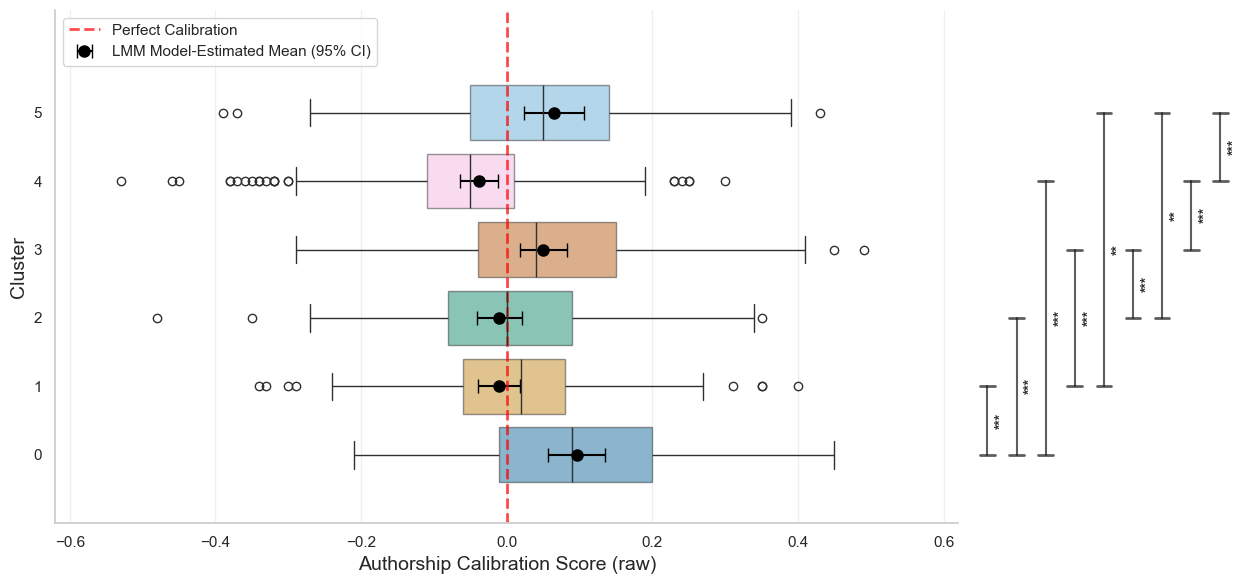

In [13]:
plot_lmm_coeffs(all_metrics, df_emmeans, clusters, df_posthoc, authorship_scores='calibration_score', n_clusters_optimal=6, name_fig='raw', save_fig=True)

## Absolute calibration scores

### LMM model

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: abs_calibration_score
No. Observations: 1241    Method:             REML                 
No. Groups:       60      Scale:              0.0062               
Min. group size:  1       Log-Likelihood:     1319.4884            
Max. group size:  87      Converged:          Yes                  
Mean group size:  20.7                                             
---------------------------------------------------------------------
                  Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------
C(cluster)[0]     0.141      0.014   10.401   0.000    0.115    0.168
C(cluster)[1]     0.095      0.009   10.134   0.000    0.076    0.113
C(cluster)[2]     0.108      0.010   10.896   0.000    0.089    0.128
C(cluster)[3]     0.138      0.010   13.196   0.000    0.118    0.159
C(cluster)[4]     0.096      0.008   11.845   0.0

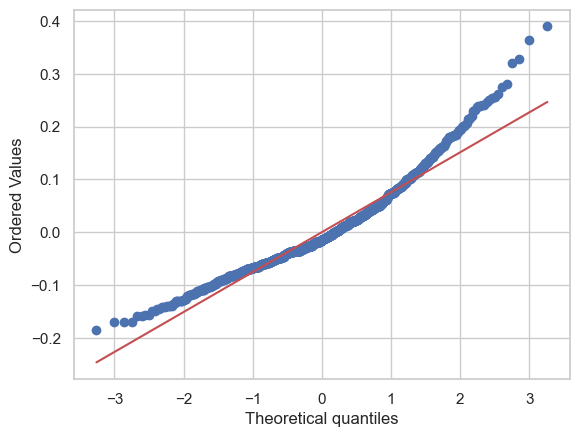

In [14]:
# Ensure cluster is treated as categorical (e.g., C(cluster_id))
all_metrics["cluster"] = all_metrics["cluster"].astype("category")

# 1. Fit the Linear Mixed Model
# 'abs_calibration_score ~ C(cluster_id)' automatically creates dummy variables
lmm_cluster_abs = smf.mixedlm(
    "abs_calibration_score ~ C(cluster) - 1",
    data=all_metrics,
    groups=all_metrics["worker_id"],
)
lmm_cluster_abs_result = lmm_cluster_abs.fit()
print(lmm_cluster_abs_result.summary())

residuals = lmm_cluster_abs_result.resid
probplot(residuals, dist="norm", plot=plt)
plt.title("")
plt.show()

In [15]:
# Extract model-based means and 95% confidence intervals for each cluster
fixed_effects_abs = lmm_cluster_abs_result.fe_params
cov_matrix_abs = lmm_cluster_abs_result.cov_params().loc[fixed_effects.index, fixed_effects.index]

clusters = sorted(all_metrics["cluster"].unique())
means_abs = []
ci_lower_abs = []
ci_upper_abs = []

for cluster in clusters:
    param_name = f"C(cluster)[{cluster}]"
    mean = float(fixed_effects_abs[param_name])
    standard_error = float(np.sqrt(cov_matrix_abs.loc[param_name, param_name]))
    means_abs.append(mean)
    ci_lower_abs.append(mean - 1.96 * standard_error)
    ci_upper_abs.append(mean + 1.96 * standard_error)

df_emmeans_abs = pd.DataFrame(
    {
        "cluster_id": clusters,
        "mean": means_abs,
        "ci_lower": ci_lower_abs,
        "ci_upper": ci_upper_abs,
    }
)

df_emmeans_abs

,cluster_id,mean,ci_lower,ci_upper
0,0,0.141420,0.114771,0.168069
1,1,0.094591,0.076297,0.112885
2,2,0.108115,0.088668,0.127563
3,3,0.138203,0.117675,0.158731
4,4,0.096424,0.080469,0.112378
5,5,0.154635,0.126607,0.182663


### Wald $\chi^2$ test

In [16]:
hypothesis = hypothesis = (
    "C(cluster)[0] = C(cluster)[1], "
    "C(cluster)[0] = C(cluster)[2], " 
    "C(cluster)[0] = C(cluster)[3], "
    "C(cluster)[0] = C(cluster)[4], "
    "C(cluster)[0] = C(cluster)[5]"
)


wald_test = lmm_cluster_abs_result.wald_test(hypothesis)
print(f"Chi2: {wald_test.statistic}")
print(f"p-value: {wald_test.pvalue}")

Chi2: [[37.13961517]]
p-value: 5.61561120038866e-07


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### T-test for pairwise comparison (with Bonferroni correction)

In [17]:
# 1. Get the fixed-effects parameter names
fe_params_abs = list(lmm_cluster_abs_result.fe_params.index)
n_params = len(fe_params_abs)

# 2. Iterate over all pairs of clusters
pairwise_results = []

for p1, p2 in combinations(fe_params_abs, 2):
    r_matrix = np.zeros(n_params)
    r_matrix[fe_params_abs.index(p1)] = 1
    r_matrix[fe_params_abs.index(p2)] = -1
    r_matrix = r_matrix.reshape(1, -1)  # Reshape to 2D for the t_test function

    # Run the t-test with the NumPy matrix
    test = lmm_cluster_abs_result.t_test(r_matrix)

    # Safely extract the values
    diff = float(np.asarray(test.effect).squeeze())
    sd = float(np.asarray(test.sd).squeeze())
    z_stat = float(np.asarray(test.tvalue).squeeze())
    p_val = float(np.asarray(test.pvalue).squeeze())

    # Clean up names for readability in the table
    label1 = p1.replace("C(cluster)[", "").replace("]", "").replace("[", "")
    label2 = p2.replace("C(cluster)[", "").replace("]", "").replace("[", "")

    pairwise_results.append(
        {
            "Comparison": f"{label1} vs {label2}",
            "Diff (p1 - p2)": diff,
            "Std_Err": sd,
            "z": z_stat,
            "p_value_raw": p_val,
        }
    )

df_posthoc_abs = pd.DataFrame(pairwise_results)

# 3. Bonferroni correction for multiple comparisons
reject, p_adjusted, _, _ = multipletests(
    df_posthoc_abs["p_value_raw"], alpha=0.05, method="bonferroni"
)

# 4. Add the adjusted columns to the DataFrame
df_posthoc_abs["p_value_bonferroni"] = p_adjusted
df_posthoc_abs["Significant (alpha=0.05)"] = reject

# Display the results
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(df_posthoc_abs)

   Comparison  Diff (p1 - p2)   Std_Err         z  p_value_raw  p_value_bonferroni  Significant (alpha=0.05)
0      0 vs 1        0.046828  0.012787  3.662239     0.000250            0.003750                      True
1      0 vs 2        0.033304  0.012813  2.599326     0.009341            0.140111                     False
2      0 vs 3        0.003216  0.013164  0.244333     0.806973            1.000000                     False
3      0 vs 4        0.044996  0.012585  3.575328     0.000350            0.005247                      True
4      0 vs 5       -0.013216  0.014585 -0.906088     0.364890            1.000000                     False
5      1 vs 2       -0.013524  0.009091 -1.487609     0.136854            1.000000                     False
6      1 vs 3       -0.043612  0.009729 -4.482835     0.000007            0.000110                      True
7      1 vs 4       -0.001833  0.007586 -0.241565     0.809117            1.000000                     False
8      1 vs 5      

In [18]:
all_metrics

,session_id,text,nb_sentences_total,nb_sentences_initial_prompt,nb_sentences_full_user,nb_sentences_full_GPT,nb_sentences_GPT_user,nb_gpt_calls,nb_used_suggestions,nb_rejected_suggestions,nb_modified_suggestions,nb_accepted_as_it_is_suggestions,timestamp,worker_id,type,written_by_human,written_by_human_decla,fluency,ideas_generation,quality,competency,writing,understanding,ease_of_use,satisfaction,confidence,ownership,willingness_to_reuse,cluster,calibration,calibration_score,abs_calibration_score
0,e0435f4cf6fc435c872ffc5b66b66b0c,"A woman has been dating guy after guy, but it ...",37,3,20,7,7,17,14,3,6,8,8/16/2021 0:21:31,A1S5KQVM900NE,creative,66,70,7.0,7.0,3.0,6.0,6.0,6.0,7.0,6.0,7.0,6.0,7.0,1,4,0.04,0.04
1,74517c6eb89c46fab708de3e3d7c53db,"When you're 28, science discovers a drug that ...",15,3,6,1,5,16,8,8,1,7,8/19/2021 14:46:01,A2WGW5Y3ZFBDEC,creative,78,80,6.0,1.0,7.0,3.0,1.0,5.0,3.0,5.0,5.0,7.0,1.0,2,2,0.02,0.02
2,91e0856327a04acb8f366faea281f072,Are We Being Bad Citizens If We Don't Keep Up ...,25,6,16,2,1,6,3,3,0,3,8/24/2021 12:28:55,AZCGF2D7QIO10,argumentative,87,90,7.0,7.0,1.0,7.0,6.0,6.0,7.0,7.0,7.0,6.0,7.0,4,3,0.03,0.03
3,ba931f5050e7409ebba26e00d532cc7c,"Following World War III, all the nations of th...",19,2,15,1,1,6,2,4,0,2,8/20/2021 4:23:35,ASVRLMDNQBUD9,creative,95,90,4.0,1.0,7.0,1.0,1.0,1.0,2.0,4.0,5.0,7.0,6.0,4,-5,-0.05,0.05
4,128bac319cb14dadaaf5c30c3a8ac5cb,"Your entire life, you've been told you're deat...",78,4,33,32,9,47,42,5,3,39,9/2/2021 0:46:34,A345TDMHP3DQ3G,creative,48,65,6.0,6.0,4.0,6.0,6.0,6.0,5.0,5.0,6.0,6.0,4.0,5,17,0.17,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1236,562cda138b314c97b21ba43f691b79ec,"When you die, you appear in a cinema with a nu...",39,2,24,5,8,18,13,5,6,7,8/16/2021 15:42:26,A2QX3YJXAAHHVV,creative,70,50,7.0,7.0,1.0,7.0,7.0,7.0,7.0,7.0,7.0,6.0,7.0,1,-20,-0.20,0.20
1237,8637ce05b848420f920d5ca02f88a89a,Should Schools Provide Free Pads and Tampons?\...,25,7,6,6,6,24,14,10,1,13,8/19/2021 7:03:16,A1QUQ0TV9KVD4C,argumentative,41,55,6.0,6.0,3.0,5.0,5.0,6.0,6.0,6.0,6.0,6.0,7.0,3,14,0.14,0.14
1238,c2395534dfb74c8ab70eec8f139ed2bc,How Do You Think Technology Affects Dating?\n\...,22,9,7,0,6,9,6,3,2,4,9/5/2021 9:08:07,A2W121DQXNQK1,argumentative,74,70,7.0,7.0,1.0,7.0,7.0,6.0,7.0,7.0,7.0,7.0,7.0,2,-4,-0.04,0.04
1239,95b8a64db3d3471f9662d0019357059d,What Are the Most Important Things Students Sh...,19,6,4,3,6,11,9,2,3,6,8/22/2021 5:51:30,A2QX3YJXAAHHVV,argumentative,49,80,6.0,5.0,1.0,7.0,6.0,7.0,7.0,7.0,7.0,7.0,7.0,1,31,0.31,0.31


/Users/treuilli/Documents/GitHub/GenAI_Interaction_Dynamics_Authorship/notebooks/../src/visualization.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


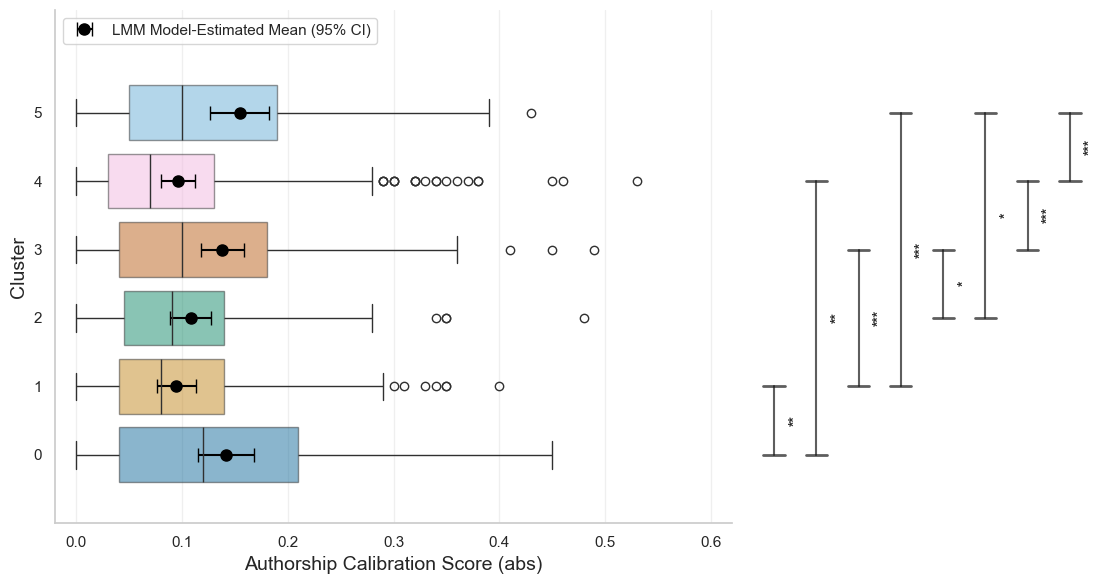

In [19]:
plot_lmm_coeffs(all_metrics, df_emmeans_abs, clusters, df_posthoc_abs, authorship_scores='abs_calibration_score', n_clusters_optimal=6, name_fig='abs', save_fig=True)

# Explore variations over repeated writing sessions

In [20]:
# Select writers with at least 5 writing sessions
multi_cluster_users = all_metrics.groupby('worker_id')['session_id'].nunique().reset_index()
multi_cluster_users = multi_cluster_users[multi_cluster_users['session_id'] > 4]['worker_id']

print(len(multi_cluster_users), "users with at least 5 sessions.")


39 users with at least 5 sessions.


In [21]:
#Filter data for these writers and add session count
df_analysed = all_metrics[all_metrics['worker_id'].isin(multi_cluster_users)]

df_analysed['timestamp'] = pd.to_datetime(df_analysed['timestamp'])
df_analysed = df_analysed.sort_values(by=['worker_id', 'timestamp'])
df_analysed['session_num'] = df_analysed.groupby('worker_id').cumcount() + 1

/var/folders/nc/7q3l6kb55dzbm2hnx3_kn63wnhywfc/T/ipykernel_43728/1178281989.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysed['timestamp'] = pd.to_datetime(df_analysed['timestamp'])


# Raw calibration scores

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: calibration_score
No. Observations: 1200    Method:             REML             
No. Groups:       39      Scale:              0.0127           
Min. group size:  5       Log-Likelihood:     853.0488         
Max. group size:  87      Converged:          Yes              
Mean group size:  30.8                                         
----------------------------------------------------------------
                 Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------
Intercept        -0.016     0.017  -0.932  0.351  -0.049   0.017
session_num       0.000     0.000   1.586  0.113  -0.000   0.001
Group Var         0.010     0.022                               



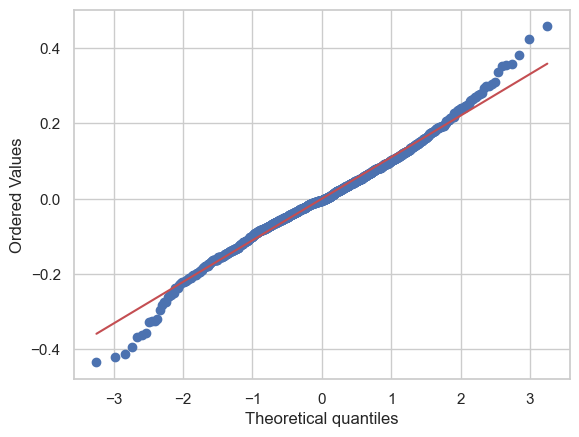

In [22]:
model = smf.mixedlm("calibration_score ~ session_num", 
                    data=df_analysed, 
                    groups=df_analysed['worker_id'])

model_raw_result = model.fit()

print(model_raw_result.summary())

residuals = model_raw_result.resid
probplot(residuals, dist="norm", plot=plt)
plt.title("")
plt.show()

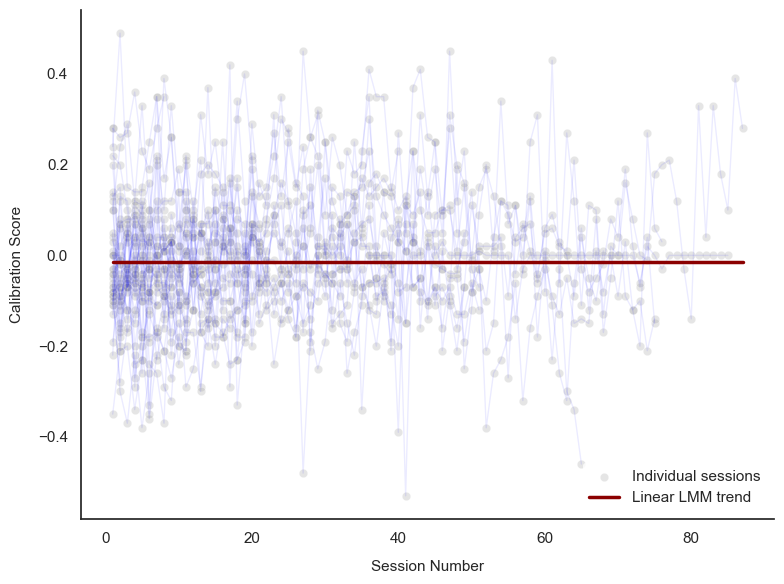

In [23]:
plot_time_evolution(df_analysed, model_raw_result, authorship_scores='calibration_score', name_fig='raw', save_fig=True)

# Absolute calibration scores

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: abs_calibration_score
No. Observations: 1200    Method:             REML                 
No. Groups:       39      Scale:              0.0064               
Min. group size:  5       Log-Likelihood:     1270.1150            
Max. group size:  87      Converged:          Yes                  
Mean group size:  30.8                                             
---------------------------------------------------------------------
                  Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------
Intercept         0.110      0.009   12.292   0.000    0.093    0.128
session_num       0.000      0.000    0.215   0.829   -0.000    0.000
Group Var         0.003      0.009                                   



/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


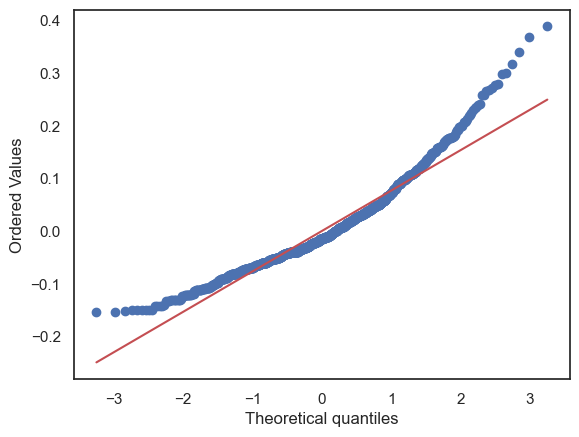

In [24]:
model = smf.mixedlm("abs_calibration_score ~ session_num", 
                    data=df_analysed, 
                    groups=df_analysed['worker_id'])

model_abs_result = model.fit()

print(model_abs_result.summary())

residuals = model_abs_result.resid
probplot(residuals, dist="norm", plot=plt)
plt.title("")
plt.show()

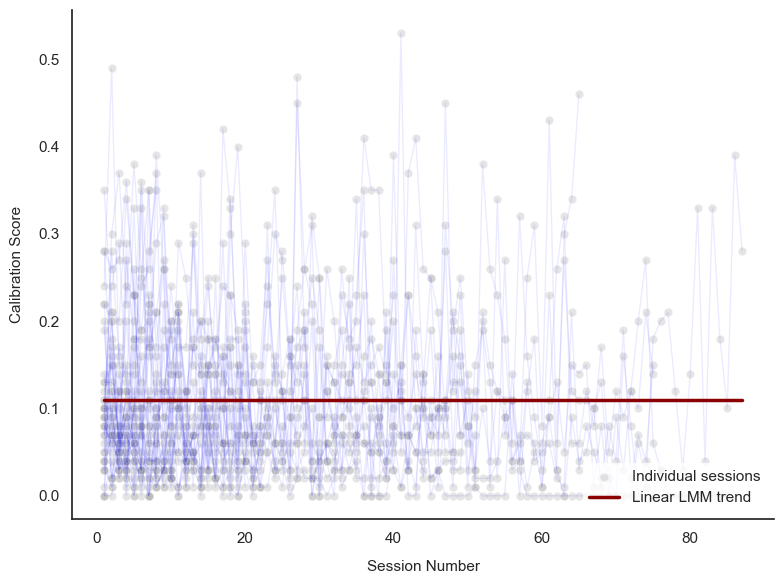

In [25]:
plot_time_evolution(df_analysed, model_abs_result, authorship_scores='abs_calibration_score', name_fig='abs', save_fig=True)